## Basic Simple Linear Regression Project

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [113]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


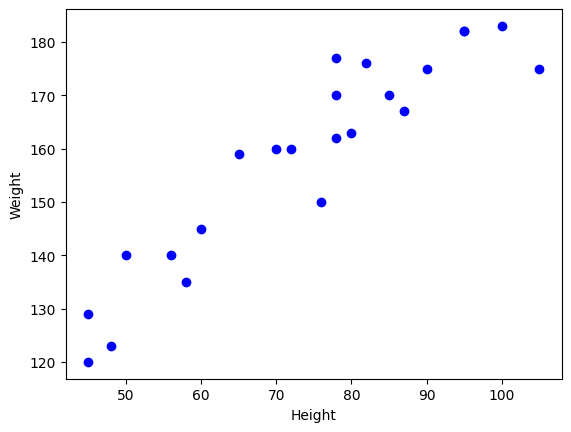

In [114]:
plt.scatter(df['Weight'], df['Height'], color='blue')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

### Steps in Machine Learning Algorithm Training
* Have the dataset ,divide it into dependent and independent features.
* Perform train-test split.
* Standardize the data.
* Train the model.
* Evaluate the model.
* Make predictions.

In [115]:
## divide data into dependent and independent features.
X = df[['Weight']] ## independent features
y = df['Height'] ## dependent features

In [116]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [117]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [118]:
## Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [119]:
X.shape,X_train.shape,X_test.shape,y.shape,y_train.shape,y_test.shape

((23, 1), (18, 1), (5, 1), (23,), (18,), (5,))

In [120]:
## Standardization of the dataset , Train the independent feature
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

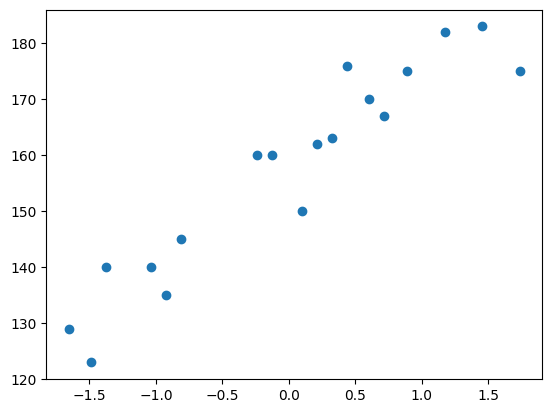

In [121]:
plt.scatter(X_train,y_train)

In [122]:
## Train the model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [123]:
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
print("The slope or coefficient of weight is",regressor.coef_)
print("Intercept :",regressor.intercept_)

The slope or coefficient of weight is [17.03440872]
Intercept : 157.5


### Linear Regression 
$h_{\theta}(x) = \theta_0 + \theta_1 x$

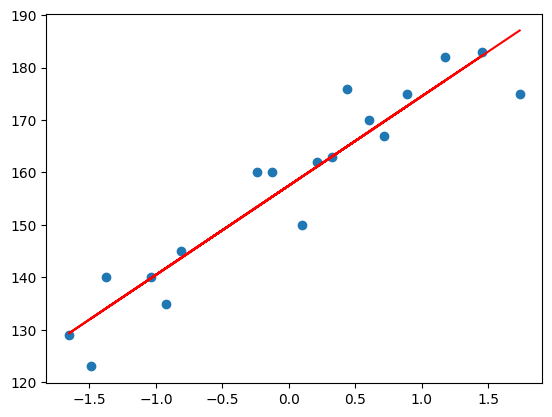

In [125]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

### prediction of train data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_train = 157.5 + 17.03440872(X_train)

In [126]:
y_pred_test = regressor.predict(X_test)
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

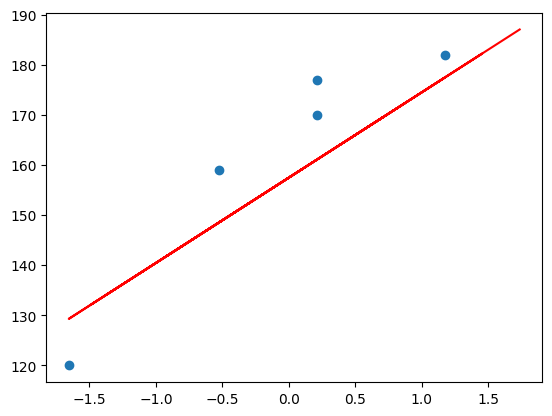

In [127]:
plt.scatter(X_test,y_test)
plt.plot(X_train,regressor.predict(X_train),'r')

### **Formulas for R Squared and Adjusted R Squared**

#### **R Squared**
$$
R^2 = 1 - \frac{\sum (y_i - \hat{y_i})^2}{\sum (y_i - \bar{y})^2}
$$

#### **Adjusted R Squared**
$$
\text{Adjusted } R^2 = 1 - (1 - R^2) \times \frac{n - 1}{n - k - 1}
$$

**Where:**
- \( n \) = number of observations  
- \( k \) = number of predictors


### **Error Metrics: MSE, RMSE, MAE**

#### **Mean Squared Error (MSE)**
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2
$$

#### **Root Mean Squared Error (RMSE)**
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2 }
$$

### **Mean Absolute Error (MAE)**

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Where:**
- \( y_i \) = actual value  
- \hat{y_i} = predicted value
- \( n \) = number of data points



In [128]:
## performance metrics
## MSE,MAE,RMSE
## R square and Adjusted R square
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)
print('Root Mean Squared Error:', rmse)

Mean Squared Error: 109.77592599051664
Mean Absolute Error: 9.822657814519232
Root Mean Squared Error: 10.477400726827081


In [129]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_test)
print('R squared:', r2)
n = len(y_test)
k = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print('Adjusted R squared:', adjusted_r2)

R squared: 0.776986986042344
Adjusted R squared: 0.7026493147231252


In [130]:
scaled_weight = scalar.transform([[80]])
scaled_weight

c:\Users\Inderjeet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [131]:
print("The height prediction for weight 80 kg is :",regressor.predict(scaled_weight))

The height prediction for weight 80 kg is : [163.01076266]


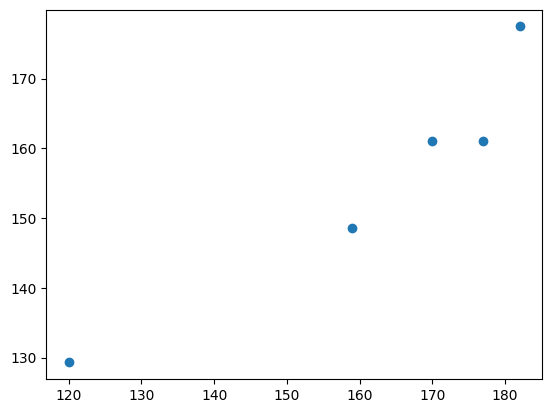

In [132]:
## Assumption
## plot a scatter for the prediction
plt.scatter(y_test,y_pred_test)

In [133]:
## residuals
residuals = y_test - y_pred_test
print(residuals)

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64


C:\Users\Inderjeet\AppData\Local\Temp\ipykernel_15376\1347100581.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

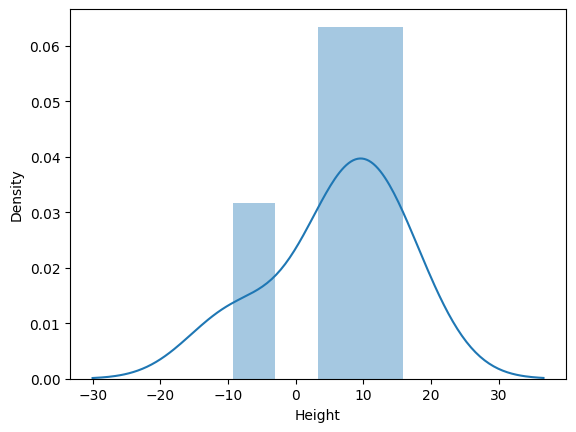

In [134]:
## plot the residuals
import seaborn as sns
sns.distplot(residuals,kde=True)

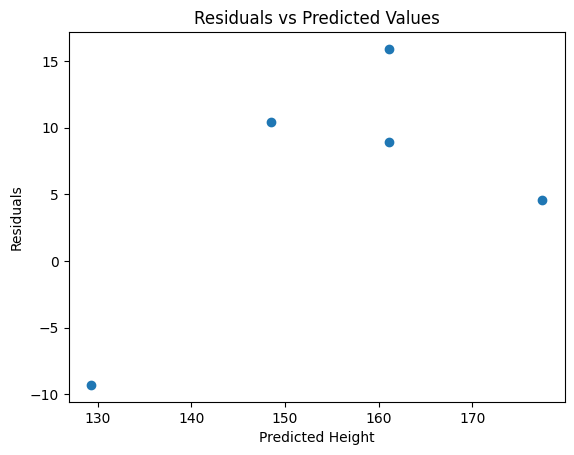

In [135]:
## Scatter plot with respect to prediction and residuals
## Uniform Distribution
plt.scatter(y_pred_test, residuals)
plt.xlabel('Predicted Height')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()